In [63]:
import numpy as np
import pandas as pd

In [64]:
df = pd.read_csv('/home/mdnaim/Github/100-days-of-machine-learning/Placement.csv')

In [65]:
df

,Student_ID,CGPA,IQ,Placement
0,1,6.8,123,1
1,2,5.9,106,0
2,3,5.3,121,0
3,4,7.4,132,1
4,5,5.8,142,0
...,...,...,...,...
95,96,4.3,200,0
96,97,4.4,42,0
97,98,6.7,182,1
98,99,6.3,103,1


In [66]:
df.head()

,Student_ID,CGPA,IQ,Placement
0,1,6.8,123,1
1,2,5.9,106,0
2,3,5.3,121,0
3,4,7.4,132,1
4,5,5.8,142,0


In [67]:
df = df.iloc[ :, 1: ]

In [68]:
df.head()

,CGPA,IQ,Placement
0,6.8,123,1
1,5.9,106,0
2,5.3,121,0
3,7.4,132,1
4,5.8,142,0


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CGPA       100 non-null    float64
 1   IQ         100 non-null    int64  
 2   Placement  100 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 2.5 KB


In [70]:
df.shape

(100, 3)

# Steps
### 0. Preprocess + EDA + Feature Selection
### 01. Extract Input and output columns
### 02. Scale the values
### 03. Train test values
### 04. Train the model
### 05. Evaluate the model/model selection
### 06. Deploy the mdel

In [71]:
import matplotlib.pyplot as plt

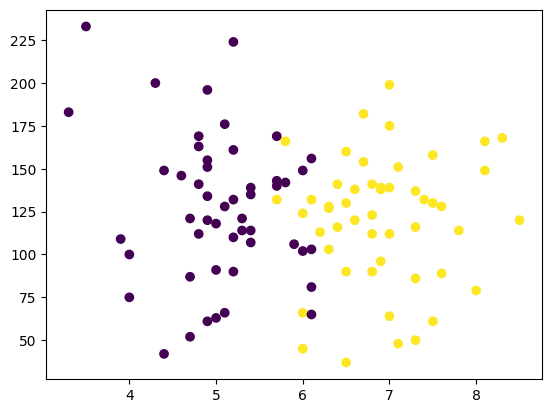

In [72]:
plt.scatter(df['CGPA'], df['IQ'], c=df['Placement'])

In [73]:
x = df.iloc[ : , 0 : 2]
y = df.iloc[ : ,-1]

In [74]:
x

,CGPA,IQ
0,6.8,123
1,5.9,106
2,5.3,121
3,7.4,132
4,5.8,142
...,...,...
95,4.3,200
96,4.4,42
97,6.7,182
98,6.3,103


In [75]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: Placement, Length: 100, dtype: int64

In [76]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1)

In [77]:
x_train

,CGPA,IQ
69,8.5,120
52,7.0,175
76,4.9,155
31,3.9,109
18,4.0,100
...,...,...
96,4.4,42
93,6.8,112
37,8.1,149
1,5.9,106


In [78]:
y_train

69    1
52    1
76    0
31    0
18    0
     ..
96    0
93    1
37    1
1     0
60    1
Name: Placement, Length: 90, dtype: int64

In [79]:
from sklearn.preprocessing import StandardScaler

In [80]:
scaler = StandardScaler()

In [81]:
X_train = scaler.fit_transform(x_train)

In [82]:
X_train

array([[ 2.18073301, -0.09149045],
       [ 0.88038426,  1.29345678],
       [-0.94010398,  0.7898396 ],
       [-1.80700315, -0.3684799 ],
       [-1.72031323, -0.59510763],
       [ 0.44693468,  0.16031813],
       [ 1.31383385,  0.86538218],
       [ 0.96707418, -1.90451228],
       [ 1.74728343, -1.12390566],
       [-0.24658465,  0.4876693 ],
       [ 2.00735318,  1.11719077],
       [-0.24658465,  1.14237163],
       [ 1.40052376, -0.87209708],
       [-1.11348382, -0.06630959],
       [ 0.27355485,  0.08477556],
       [ 0.44693468,  0.9157439 ],
       [-0.76672415, -1.45125683],
       [ 1.83397334,  1.06682905],
       [ 1.40052376,  0.10995642],
       [-0.24658465,  0.41212672],
       [ 1.57390359, -0.24257561],
       [ 0.10017501,  0.81502046],
       [ 1.22714393,  0.21067985],
       [-0.76672415,  1.31863764],
       [-0.24658465,  0.21067985],
       [-2.15376281,  2.75394659],
       [-0.76672415,  0.10995642],
       [ 0.36024476,  0.43730758],
       [ 0.62031451,

In [83]:
X_test = scaler.transform(x_test)

In [84]:
x_test

,CGPA,IQ
95,4.3,200
41,5.4,114
44,7.5,61
74,6.7,154
46,5.3,114
7,5.0,63
21,7.1,151
32,7.0,139
71,6.1,132
14,6.1,103


In [85]:
from sklearn.linear_model import LogisticRegression

In [86]:
clf = LogisticRegression()

In [87]:
# Model Train
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [88]:
y_pred = clf.predict(X_test)

In [89]:
y_test

95    0
41    0
44    1
74    1
46    0
7     0
21    1
32    1
71    1
14    0
Name: Placement, dtype: int64

In [90]:
from sklearn.metrics import accuracy_score

In [91]:
accuracy_score(y_test, y_pred)

0.9

In [92]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

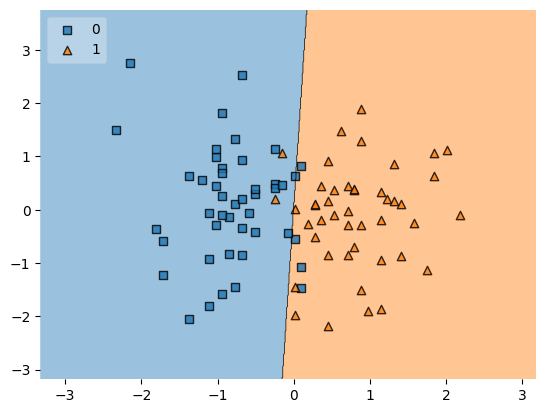

In [95]:
plot_decision_regions(
    X_train, 
    y_train.values, 
    clf = clf, 
    legend=2
)